<a href="https://colab.research.google.com/github/brunopn-code/workflow-performance-analytics/blob/main/workflow-performance-analytics/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

The full processed dataset is not included in this repository due to file size. A sample file is available in `data/sample/`.

In [2]:
df = pd.read_csv("bpi_2012_events.csv")

In [3]:
df.head()

,resource,lifecycle_transition,activity,timestamp,case_registration_date,case_id,amount_requested
0,112.0,COMPLETE,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
1,112.0,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
2,112.0,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
3,112.0,SCHEDULE,W_Completeren aanvraag,2011-10-01 00:39:38.875000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262200 entries, 0 to 262199
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   resource                244190 non-null  float64
 1   lifecycle_transition    262200 non-null  object 
 2   activity                262200 non-null  object 
 3   timestamp               262200 non-null  object 
 4   case_registration_date  262200 non-null  object 
 5   case_id                 262200 non-null  int64  
 6   amount_requested        262200 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 14.0+ MB


In [5]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="mixed",
    utc=True
)

df["case_registration_date"] = pd.to_datetime(
    df["case_registration_date"],
    format="mixed",
    utc=True
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262200 entries, 0 to 262199
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   resource                244190 non-null  float64            
 1   lifecycle_transition    262200 non-null  object             
 2   activity                262200 non-null  object             
 3   timestamp               262200 non-null  datetime64[ns, UTC]
 4   case_registration_date  262200 non-null  datetime64[ns, UTC]
 5   case_id                 262200 non-null  int64              
 6   amount_requested        262200 non-null  int64              
dtypes: datetime64[ns, UTC](2), float64(1), int64(2), object(2)
memory usage: 14.0+ MB


In [7]:
print("Number of events:", len(df))
print("Number of cases:", df["case_id"].nunique())
print("Number of activities:", df["activity"].nunique())
print("Number of resources:", df["resource"].nunique())

print("\nDate range:")
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())
df["activity"].value_counts()

Number of events: 262200
Number of cases: 13087
Number of activities: 24
Number of resources: 68

Date range:
Start: 2011-10-01 00:38:44.546000+00:00
End: 2012-03-14 16:04:54.681000+00:00


,count
activity,
W_Completeren aanvraag,54850
W_Nabellen offertes,52016
W_Nabellen incomplete dossiers,25190
W_Valideren aanvraag,20809
W_Afhandelen leads,16566
A_SUBMITTED,13087
A_PARTLYSUBMITTED,13087
A_DECLINED,7635
A_PREACCEPTED,7367


In [8]:
activity_frequency = (
    df["activity"]
    .value_counts()
    .reset_index()
)

activity_frequency.columns = ["activity", "event_count"]

activity_frequency["event_percentage"] = (
    activity_frequency["event_count"] / activity_frequency["event_count"].sum() * 100
).round(2)

activity_frequency

,activity,event_count,event_percentage
0,W_Completeren aanvraag,54850,20.92
1,W_Nabellen offertes,52016,19.84
2,W_Nabellen incomplete dossiers,25190,9.61
3,W_Valideren aanvraag,20809,7.94
4,W_Afhandelen leads,16566,6.32
5,A_SUBMITTED,13087,4.99
6,A_PARTLYSUBMITTED,13087,4.99
7,A_DECLINED,7635,2.91
8,A_PREACCEPTED,7367,2.81
9,O_SENT,7030,2.68


## Activity Frequency Analysis

Analysis of how often each workflow activity appears in the event log.

High-frequency activities may indicate important process steps, repeated work, or possible bottlenecks that deserve deeper investigation.

In [9]:
activity_frequency.head(10)

,activity,event_count,event_percentage
0,W_Completeren aanvraag,54850,20.92
1,W_Nabellen offertes,52016,19.84
2,W_Nabellen incomplete dossiers,25190,9.61
3,W_Valideren aanvraag,20809,7.94
4,W_Afhandelen leads,16566,6.32
5,A_SUBMITTED,13087,4.99
6,A_PARTLYSUBMITTED,13087,4.99
7,A_DECLINED,7635,2.91
8,A_PREACCEPTED,7367,2.81
9,O_SENT,7030,2.68


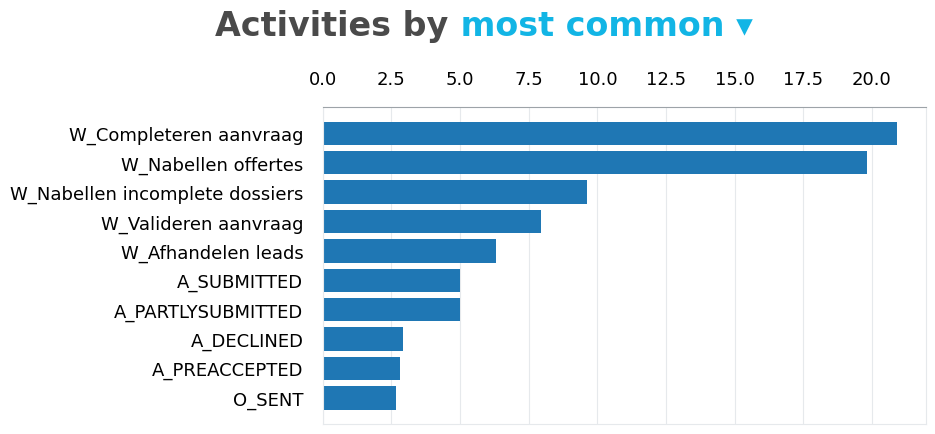

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(
    activity_frequency["activity"].head(10),
    activity_frequency["event_percentage"].head(10),
)

ax.invert_yaxis()

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(axis="x", labelsize=13, length=0, pad=14)
ax.tick_params(axis="y", labelsize=13, length=0, pad=14)

ax.grid(axis="x", color="#e6e9ec")
ax.set_axisbelow(True)

ax.spines["top"].set_color("#9da3a8")

for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_color("#e6e9ec")

fig.text(
    0.16, 0.93,
    "Activities by ",
    fontsize=24,
    fontweight="bold",
    color="#4a4a4a"
)

fig.text(
    0.42, 0.93,
    " most common ▾",
    fontsize=24,
    fontweight="bold",
    color="#12b5e5"
)

plt.subplots_adjust(left=0.28, right=0.95, top=0.78, bottom=0.12)

plt.show()

In [11]:
case_duration = (
    df.groupby("case_id")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp","max"),
        event_count=("activity","count"),
        unique_activities=("activity", "nunique"),
        amount_requested=("amount_requested", "first")
    )
    .reset_index()
)

case_duration["duration_hours"] = ((
    case_duration["end_time"] - case_duration["start_time"]
).dt.total_seconds() / 3600).round(0).astype(int)

case_duration["duration_days"] = (case_duration["duration_hours"] / 24).round(0).astype(int)

case_duration.sort_values("case_id").head(10)

,case_id,start_time,end_time,event_count,unique_activities,amount_requested,duration_hours,duration_days
0,173688,2011-10-01 00:38:44.546000+00:00,2011-10-13 10:37:37.026000+00:00,26,16,20000,298,12
1,173691,2011-10-01 08:08:58.256000+00:00,2011-10-10 14:17:34.633000+00:00,39,17,5000,222,9
2,173694,2011-10-01 08:10:30.287000+00:00,2012-02-15 12:29:26.299000+00:00,59,18,7000,3292,137
3,173697,2011-10-01 08:11:08.866000+00:00,2011-10-01 08:11:46.420000+00:00,3,3,15000,0,0
4,173700,2011-10-01 08:15:39.894000+00:00,2011-10-01 08:16:21.037000+00:00,3,3,5000,0,0
5,173703,2011-10-01 09:45:25.806000+00:00,2011-10-01 13:02:12.557000+00:00,9,5,13500,3,0
6,173706,2011-10-01 09:45:37.274000+00:00,2011-10-01 15:00:02.537000+00:00,14,6,18000,5,0
7,173709,2011-10-01 09:57:42.994000+00:00,2011-11-01 09:15:08.387000+00:00,12,5,11000,743,31
8,173712,2011-10-01 09:58:30.533000+00:00,2011-10-03 14:42:55.584000+00:00,14,6,30000,53,2
9,173715,2011-10-01 09:59:10.501000+00:00,2011-10-13 11:05:28.082000+00:00,24,14,45000,289,12


In [12]:
case_duration["duration_days"].describe()

,duration_days
count,13087.000000
mean,8.643463
std,12.170174
min,0.000000
25%,0.000000
50%,1.000000
75%,14.000000
max,137.000000


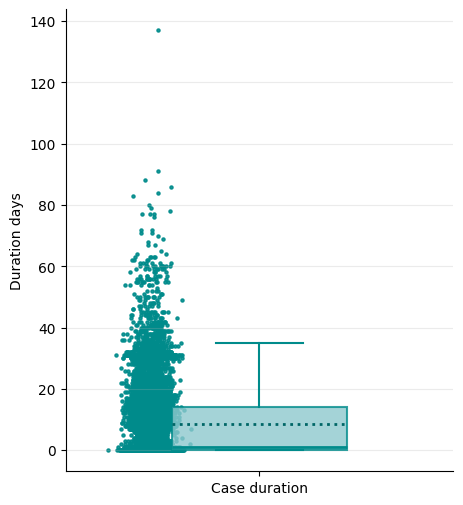

In [13]:
fig, ax = plt.subplots(figsize=(5, 6))

ax.boxplot(
    case_duration["duration_days"],
    positions=[1],
    widths=0.45,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    boxprops=dict(facecolor="#8ec9ce", color="#008b8b", linewidth=1.5, alpha=0.8),
    medianprops=dict(color="#008b8b", linewidth=2),
    meanprops=dict(color="#006666", linestyle=":", linewidth=2),
    whiskerprops=dict(color="#008b8b", linewidth=1.5),
    capprops=dict(color="#008b8b", linewidth=1.5),
    flierprops=dict(marker="")
)

rng = np.random.default_rng(42)
x_jitter = rng.normal(loc=0.72, scale=0.025, size=len(case_duration["duration_days"]))

ax.scatter(
    x_jitter,
    case_duration["duration_days"],
    color="#008b8b",
    s=5,
    alpha=0.9
)

ax.set_xticks([1])
ax.set_xticklabels(["Case duration"])
ax.set_ylabel("Duration days")
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


In [14]:
def classify_duration(days):
  if days == 0:
    return "Same day"
  elif days <= 1:
    return "1 day"
  elif days <= 14:
    return "2-14 days"
  elif days <= 40:
    return "15-40 days"
  else:
    return "Over 40 days"

case_duration["duration_category"] = case_duration["duration_days"].apply(classify_duration)

duration_categories = (
      case_duration["duration_category"]
      .value_counts()
      .reset_index()
  )

duration_categories.columns = ["duration_category", "case_counts"]

duration_categories["case_percentage"] = (
      duration_categories["case_counts"] / duration_categories["case_counts"].sum() * 100
  ).round(2)

duration_categories

,duration_category,case_counts,case_percentage
0,Same day,6125,46.80
1,15-40 days,3031,23.16
2,2-14 days,2869,21.92
3,1 day,855,6.53
4,Over 40 days,207,1.58


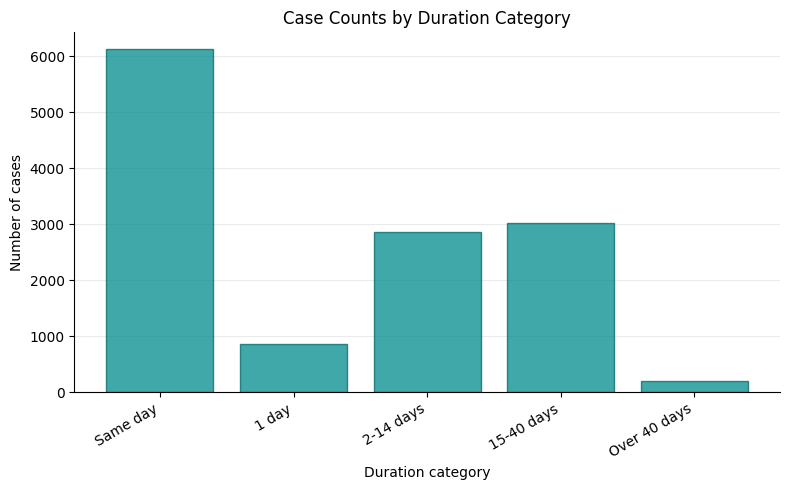

In [15]:
order = ["Same day", "1 day", "2-14 days", "15-40 days", "Over 40 days"]

duration_categories["duration_category"] = pd.Categorical(
    duration_categories["duration_category"],
    categories=order,
    ordered=True
)

duration_categories =  duration_categories.sort_values("duration_category")

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    duration_categories["duration_category"],
    duration_categories["case_counts"],
    color="#008b8b",
    alpha=0.75,
    edgecolor="#006666"
)

ax.set_xlabel("Duration category")
ax.set_ylabel("Number of cases")
ax.set_title("Case Counts by Duration Category")

# Rotate x labels so they do not overlap
plt.xticks(rotation=30, ha="right")

# Add light horizontal gridlines
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

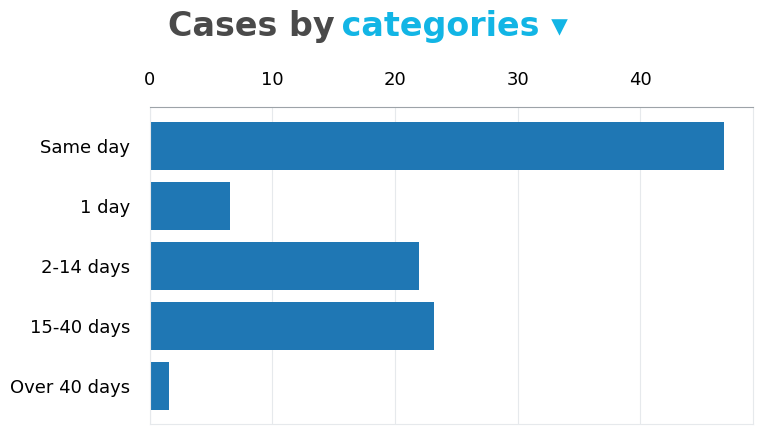

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(
    duration_categories["duration_category"],
    duration_categories["case_percentage"]
)

ax.invert_yaxis()

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(axis="x", labelsize=13, length=0, pad=14)
ax.tick_params(axis="y", labelsize=13, length=0, pad=14)

ax.grid(axis="x", color="#e6e9ec")
ax.set_axisbelow(True)

ax.spines["top"].set_color("#9da3a8")

for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_color("#e6e9ec")

fig.text(
    0.30, 0.93,
    "Cases by ",
    fontsize=24,
    fontweight="bold",
    color="#4a4a4a"
)

fig.text(
    0.48, 0.93,
    " categories ▾",
    fontsize=24,
    fontweight="bold",
    color="#12b5e5"
)

plt.subplots_adjust(left=0.28, right=0.95, top=0.78, bottom=0.12)

plt.show()

##Initial findings

THe dataset contains 262200 events or entries, that encapsulate 13087 cases, with 24 unique activities and 68 resources. It ranges from 2011-10-01 to 2012-03-14.

The event log contains application milestones (A_), offer milestones (O_), and operational workflow tasks (W_). The analysis focuses especially on W_ activities because they represent manual process work where bottlenecks, delays, and rework are more likely to occur.

Exploring the activities we found that there are 2 main activies that are most commom ,encompasing almost 40% of the activities of the dataset.

Those being "W_Completeren aanvraag" and "W_Nabellen offertes", which are operations regarding the completion and follow-up of loans.

The cases duration analysis show us that most cases are finished on the same day, but a great number of other cases takes from 1 to 40 days to complete, which might signify some bottlenecks in some of the activities.

The duration categories were defined based on the distribution of case duration. Since the 75th percentile is 14 days, cases between 1 and 14 days represent the normal range of completed cases. Cases between 15 and 40 days are treated as delayed cases because they are above the third quartile. Cases above 40 days are treated as very delayed cases because they appear in the long tail of the distribution and behave like outliers.


-------

##Repetition analysis

Analysis of repeated activities, at first the overall across the dataset so we can create a baseline then focusing of the duration groups especially 15-40 days.

Although the analysis initially focuses on W_ activities because they represent manual operational work, bottleneck analysis will not be restricted to them. Application (A_) and offer (O_) milestones can also reveal delays between process states, so subsequent analysis considers the full event log.

In [17]:
df_work_completed = df[(df["activity"].str.startswith("W_"))
& (df["lifecycle_transition"].str.lower() == "complete")].copy()

print("Completed W_ events:", len(df_work_completed))
print("Unique W activities:",df_work_completed["activity"].nunique())
print("Completed cases with W activities:", df_work_completed["case_id"].nunique())

Completed W_ events: 72413
Unique W activities: 6
Completed cases with W activities: 9658


In [18]:
work_case_activity_count = (
    df_work_completed
    .groupby(["case_id", "activity"])
    .size()
    .reset_index(name="activity_count")
)

work_rework = work_case_activity_count[work_case_activity_count["activity_count"] > 1].copy()

work_rework.describe()

,case_id,activity_count
count,13041.000000,13041.000000
mean,194146.647650,4.858293
std,11808.611566,4.189237
min,173688.000000,2.000000
25%,183405.000000,2.000000
50%,194731.000000,3.000000
75%,204379.000000,6.000000
max,214364.000000,60.000000


In [19]:
work_rework_with_duration = work_rework.merge(
    case_duration[["case_id", "duration_days", "duration_category"]],
    on="case_id",
    how="left"
)

work_rework_with_duration.head().sort_values("case_id")

,case_id,activity,activity_count,duration_days,duration_category
0,173688,W_Nabellen offertes,3,12,2-14 days
1,173691,W_Completeren aanvraag,2,9,2-14 days
2,173691,W_Nabellen offertes,4,9,2-14 days
3,173691,W_Valideren aanvraag,3,9,2-14 days
4,173694,W_Completeren aanvraag,4,137,Over 40 days


In [20]:
work_rework_by_duration = (
    work_rework_with_duration
    .groupby(["duration_category", "activity"])
    .agg(
        cases_with_rework=("case_id", "nunique"),
        avg_repetitions_per_reworked_case=("activity_count", "mean"),
        max_repetitions_in_case=("activity_count", "max")
    )
    .reset_index()
    .sort_values(["duration_category", "cases_with_rework"], ascending=[True, False])
)

work_rework_by_duration

,duration_category,activity,cases_with_rework,avg_repetitions_per_reworked_case,max_repetitions_in_case
2,1 day,W_Completeren aanvraag,413,3.254237,10
0,1 day,W_Afhandelen leads,142,2.542254,8
1,1 day,W_Beoordelen fraude,20,2.450000,6
4,1 day,W_Nabellen offertes,8,3.625000,6
5,1 day,W_Valideren aanvraag,7,2.571429,4
3,1 day,W_Nabellen incomplete dossiers,6,3.500000,7
10,15-40 days,W_Nabellen offertes,2433,5.991780,30
8,15-40 days,W_Completeren aanvraag,2003,5.755367,34
11,15-40 days,W_Valideren aanvraag,1062,3.469868,16
9,15-40 days,W_Nabellen incomplete dossiers,868,7.949309,45


In [21]:
df_all_completed = df[
    df["lifecycle_transition"].str.lower() == "complete"
].copy()

print("Completed events:", len(df_all_completed))
print("Unique activities:", df_all_completed["activity"].nunique())
print("Cases with completed events:", df_all_completed["case_id"].nunique())

Completed events: 164506
Unique activities: 23
Cases with completed events: 13087


In [22]:
all_case_activity_counts = (
    df_all_completed
    .groupby(["case_id", "activity"])
    .size()
    .reset_index(name="activity_count")
)

all_repeated_activities = all_case_activity_counts[
    all_case_activity_counts["activity_count"] > 1
].copy()

all_repeated_activities.describe()

,case_id,activity_count
count,18301.000000,18301.000000
mean,194229.966177,4.144965
std,11680.642008,3.731702
min,173688.000000,2.000000
25%,183528.000000,2.000000
50%,195042.000000,3.000000
75%,204212.000000,5.000000
max,214364.000000,60.000000


In [23]:
all_repetition_with_duration = all_repeated_activities.merge(
    case_duration[["case_id", "duration_days", "duration_category"]],
    on="case_id",
    how="left"
)

all_repetition_with_duration.head().sort_values("case_id")

,case_id,activity,activity_count,duration_days,duration_category
0,173688,W_Nabellen offertes,3,12,2-14 days
1,173691,O_CREATED,2,9,2-14 days
2,173691,O_SELECTED,2,9,2-14 days
3,173691,O_SENT,2,9,2-14 days
4,173691,W_Completeren aanvraag,2,9,2-14 days


In [24]:
all_repetition_by_duration = (
    all_repetition_with_duration
    .groupby(["duration_category", "activity"])
    .agg(
        cases_with_repetition=("case_id", "nunique"),
        avg_repetitions_per_repeated_case=("activity_count", "mean"),
        max_repetitions_in_case=("activity_count", "max")
    )
    .reset_index()
    .sort_values(["duration_category", "cases_with_repetition"], ascending=[True, False])
)

all_repetition_by_duration

,duration_category,activity,cases_with_repetition,avg_repetitions_per_repeated_case,max_repetitions_in_case
6,1 day,W_Completeren aanvraag,413,3.254237,10
4,1 day,W_Afhandelen leads,142,2.542254,8
5,1 day,W_Beoordelen fraude,20,2.450000,6
8,1 day,W_Nabellen offertes,8,3.625000,6
9,1 day,W_Valideren aanvraag,7,2.571429,4
7,1 day,W_Nabellen incomplete dossiers,6,3.500000,7
1,1 day,O_CREATED,3,2.333333,3
2,1 day,O_SELECTED,3,2.333333,3
3,1 day,O_SENT,3,2.333333,3
0,1 day,O_CANCELLED,1,2.000000,2


In [25]:
work_rework_delayed = work_rework_by_duration[
    work_rework_by_duration["duration_category"].isin(["2-14 days","15-40 days", "Over 40 days"])
]

work_rework_delayed.sort_values(["duration_category", "cases_with_rework"], ascending=[True, False])

,duration_category,activity,cases_with_rework,avg_repetitions_per_reworked_case,max_repetitions_in_case
10,15-40 days,W_Nabellen offertes,2433,5.991780,30
8,15-40 days,W_Completeren aanvraag,2003,5.755367,34
11,15-40 days,W_Valideren aanvraag,1062,3.469868,16
9,15-40 days,W_Nabellen incomplete dossiers,868,7.949309,45
6,15-40 days,W_Afhandelen leads,149,2.583893,9
7,15-40 days,W_Beoordelen fraude,12,3.083333,6
16,2-14 days,W_Nabellen offertes,1622,3.206535,13
14,2-14 days,W_Completeren aanvraag,1592,4.246231,24
17,2-14 days,W_Valideren aanvraag,862,3.003480,12
15,2-14 days,W_Nabellen incomplete dossiers,513,4.886940,25


In [26]:
all_repetition_delayed = all_repetition_by_duration[
    all_repetition_by_duration["duration_category"].isin(["2-14 days","15-40 days", "Over 40 days"])
]

all_repetition_delayed.sort_values(["duration_category", "cases_with_repetition"], ascending=[True, False])

,duration_category,activity,cases_with_repetition,avg_repetitions_per_repeated_case,max_repetitions_in_case
19,15-40 days,W_Nabellen offertes,2433,5.991780,30
17,15-40 days,W_Completeren aanvraag,2003,5.755367,34
20,15-40 days,W_Valideren aanvraag,1062,3.469868,16
18,15-40 days,W_Nabellen incomplete dossiers,868,7.949309,45
11,15-40 days,O_CREATED,818,2.420538,7
12,15-40 days,O_SELECTED,818,2.420538,7
13,15-40 days,O_SENT,818,2.420538,7
10,15-40 days,O_CANCELLED,411,2.328467,6
14,15-40 days,O_SENT_BACK,156,2.019231,3
15,15-40 days,W_Afhandelen leads,149,2.583893,9


In [27]:
# Number of cases per duration category
cases_by_duration = (
    case_duration
    .groupby("duration_category")
    .agg(total_cases=("case_id", "nunique"))
    .reset_index()
)

cases_by_duration

,duration_category,total_cases
0,1 day,855
1,15-40 days,3031
2,2-14 days,2869
3,Over 40 days,207
4,Same day,6125


In [28]:
work_rework_with_rates = all_repetition_by_duration.merge(
    cases_by_duration,
    on="duration_category",
    how="left"
)

work_rework_with_rates["rework_case_rate"] = (
    work_rework_with_rates["cases_with_repetition"]
    / work_rework_with_rates["total_cases"]
    * 100
).round(2)

work_rework_with_rates[
    work_rework_with_rates["duration_category"].isin(["2-14 days","15-40 days", "Over 40 days"])
].sort_values(["duration_category", "rework_case_rate"], ascending=[True, False])

,duration_category,activity,cases_with_repetition,avg_repetitions_per_repeated_case,max_repetitions_in_case,total_cases,rework_case_rate
10,15-40 days,W_Nabellen offertes,2433,5.991780,30,3031,80.27
11,15-40 days,W_Completeren aanvraag,2003,5.755367,34,3031,66.08
12,15-40 days,W_Valideren aanvraag,1062,3.469868,16,3031,35.04
13,15-40 days,W_Nabellen incomplete dossiers,868,7.949309,45,3031,28.64
14,15-40 days,O_CREATED,818,2.420538,7,3031,26.99
15,15-40 days,O_SELECTED,818,2.420538,7,3031,26.99
16,15-40 days,O_SENT,818,2.420538,7,3031,26.99
17,15-40 days,O_CANCELLED,411,2.328467,6,3031,13.56
18,15-40 days,O_SENT_BACK,156,2.019231,3,3031,5.15
19,15-40 days,W_Afhandelen leads,149,2.583893,9,3031,4.92


In [29]:
work_rework_with_rates_2_14 = work_rework_with_rates[
    work_rework_with_rates["duration_category"] == "2-14 days"
]

work_rework_with_rates_15_40 = work_rework_with_rates[
    work_rework_with_rates["duration_category"] == "15-40 days"
]

work_rework_with_rates_over_40 = work_rework_with_rates[
    work_rework_with_rates["duration_category"] == "Over 40 days"
]

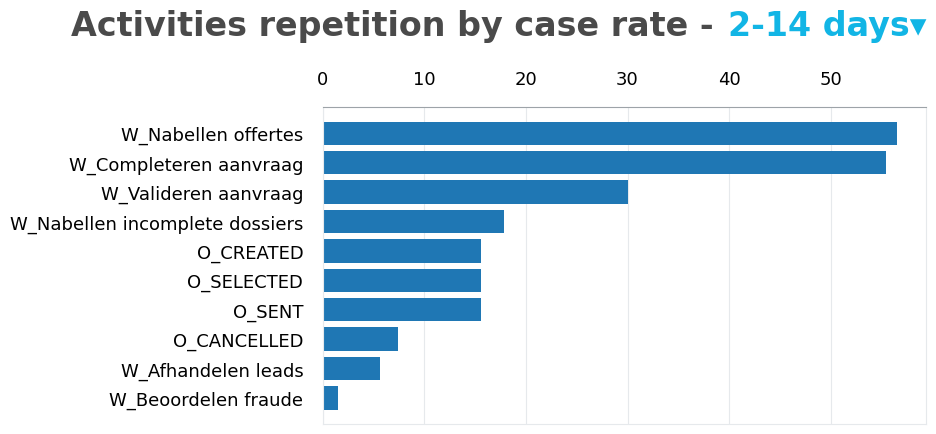

In [30]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(
    work_rework_with_rates_2_14["activity"].head(10),
    work_rework_with_rates_2_14["rework_case_rate"].head(10),
)

ax.invert_yaxis()

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(axis="x", labelsize=13, length=0, pad=14)
ax.tick_params(axis="y", labelsize=13, length=0, pad=14)

ax.grid(axis="x", color="#e6e9ec")
ax.set_axisbelow(True)

ax.spines["top"].set_color("#9da3a8")

for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_color("#e6e9ec")

fig.text(
    0.00, 0.93,
    "Activities repetition by case rate - ",
    fontsize=24,
    fontweight="bold",
    color="#4a4a4a"
)

fig.text(
    0.73, 0.93,
    "2-14 days▾",
    fontsize=24,
    fontweight="bold",
    color="#12b5e5"
)

plt.subplots_adjust(left=0.28, right=0.95, top=0.78, bottom=0.12)

plt.show()

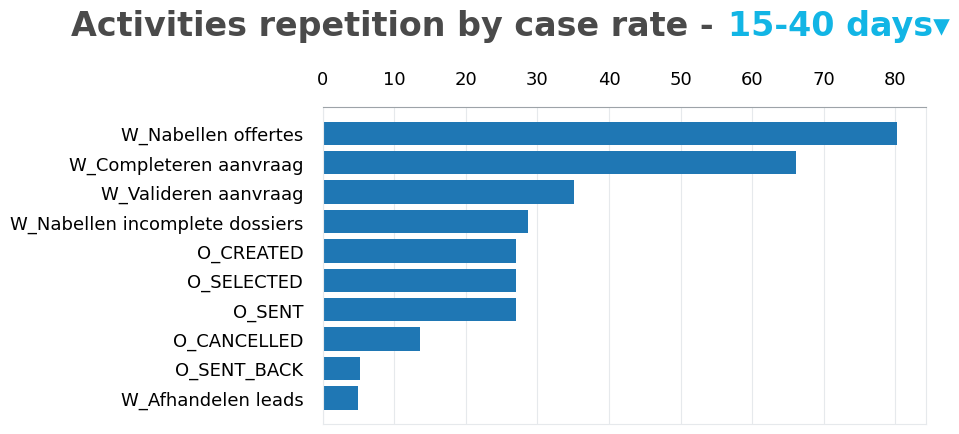

In [31]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(
    work_rework_with_rates_15_40["activity"].head(10),
    work_rework_with_rates_15_40["rework_case_rate"].head(10),
)

ax.invert_yaxis()

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(axis="x", labelsize=13, length=0, pad=14)
ax.tick_params(axis="y", labelsize=13, length=0, pad=14)

ax.grid(axis="x", color="#e6e9ec")
ax.set_axisbelow(True)

ax.spines["top"].set_color("#9da3a8")

for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_color("#e6e9ec")

fig.text(
    0.00, 0.93,
    "Activities repetition by case rate - ",
    fontsize=24,
    fontweight="bold",
    color="#4a4a4a"
)

fig.text(
    0.73, 0.93,
    "15-40 days▾",
    fontsize=24,
    fontweight="bold",
    color="#12b5e5"
)

plt.subplots_adjust(left=0.28, right=0.95, top=0.78, bottom=0.12)

plt.show()

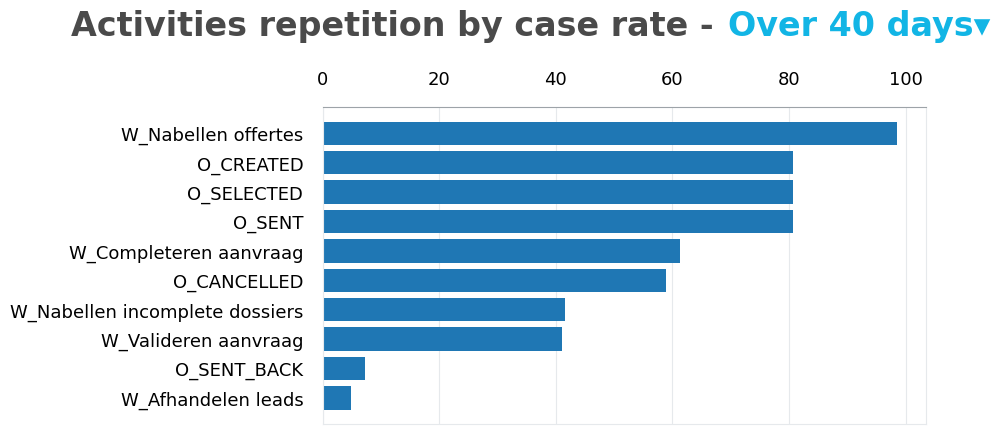

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(
    work_rework_with_rates_over_40["activity"].head(10),
    work_rework_with_rates_over_40["rework_case_rate"].head(10),
)

ax.invert_yaxis()

ax.xaxis.tick_top()
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
ax.tick_params(axis="x", labelsize=13, length=0, pad=14)
ax.tick_params(axis="y", labelsize=13, length=0, pad=14)

ax.grid(axis="x", color="#e6e9ec")
ax.set_axisbelow(True)

ax.spines["top"].set_color("#9da3a8")

for spine in ["left", "right", "bottom"]:
    ax.spines[spine].set_color("#e6e9ec")

fig.text(
    0.00, 0.93,
    "Activities repetition by case rate - ",
    fontsize=24,
    fontweight="bold",
    color="#4a4a4a"
)

fig.text(
    0.73, 0.93,
    "Over 40 days▾",
    fontsize=24,
    fontweight="bold",
    color="#12b5e5"
)

plt.subplots_adjust(left=0.28, right=0.95, top=0.78, bottom=0.12)

plt.show()

##Repetition Analysis FIndings
The repetition analysis shows which activities are repeated within the same case across different duration categories.

For the 2–14 days and 15–40 days categories, most repeated activities are operational workflow tasks (W_). The most frequent repeated activities are W_Nabellen offertes, W_Completeren aanvraag, W_Valideren aanvraag, and W_Nabellen incomplete dossiers.

This does not necessarily mean that these activities are the direct cause of process delays. These activities are also among the most common activities in the dataset, so their high repetition rate must be interpreted carefully.

However, the results suggest that delayed cases are strongly associated with repeated applicant follow-up, application completion, validation, and incomplete dossier handling.

For the Over 40 days category, repeated offer milestones (O_) become much more visible, especially O_CREATED, O_SELECTED, and O_SENT. These offer-related activities appear less frequently in the overall dataset, so their higher presence in very long cases may indicate repeated offer cycles.

This suggests that very delayed cases may not only be affected by repeated manual workflow tasks, but also by repeated offer creation, selection, and sending.

At this stage, the analysis does not prove causality. Instead, it identifies activities and process patterns that are associated with longer case durations and should be investigated further.

The next step is to analyze activity duration and waiting time between activities. This will help determine whether delays are caused by activities taking longer to complete, activities being repeated many times, long waiting periods between activities, or a combination of these factors.

-----

##Activity Duration Analysis

The previous analysis showed that delayed cases are associated with repeated activities.

However, repetition alone does not explain whether delays happen because activities are repeated many times, because individual activities take a long time to complete, or both.

This section estimates activity duration by pairing `start` and `complete` lifecycle events for workflow activities (`W_`). The duration is calculated as the time between the start timestamp and the complete timestamp of the same activity occurrence.

In [33]:
df["lifecycle_transition"].value_counts()

,count
lifecycle_transition,
COMPLETE,164506
START,71376
SCHEDULE,26318


In [34]:
df["transition"] = df["lifecycle_transition"].str.lower()

df_work_lifecycle = df[df["activity"].str.startswith("W_") & (df["transition"].isin(["start", "complete"]))].copy()

df_work_lifecycle = df_work_lifecycle.sort_values(["case_id","activity", "timestamp"])

df_work_lifecycle.head()

,resource,lifecycle_transition,activity,timestamp,case_registration_date,case_id,amount_requested,transition
4,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start
11,NaN,COMPLETE,W_Completeren aanvraag,2011-10-01 11:45:13.917000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete
12,NaN,START,W_Nabellen offertes,2011-10-01 12:15:41.290000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start
13,NaN,COMPLETE,W_Nabellen offertes,2011-10-01 12:17:08.924000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete
14,10913.0,START,W_Nabellen offertes,2011-10-08 16:26:57.720000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start


In [35]:
starts = df[df["transition"] == "start"].copy()
completes = df[df["transition"] == "complete"].copy()

starts["activity_ocurrence"] = (
    starts
    .groupby(["case_id", "activity"])
    .cumcount() + 1
)

completes["activity_ocurrence"] = (
    completes
    .groupby(["case_id", "activity"])
    .cumcount() + 1
)

activity_pairs = starts.merge(
    completes,
    on=["case_id", "activity", "activity_ocurrence"],
    suffixes = ("_start", "_complete"),
    how="inner"
)

activity_pairs.sort_values(["case_id", "activity_ocurrence"]).head()

,resource_start,lifecycle_transition_start,activity,timestamp_start,case_registration_date_start,case_id,amount_requested_start,transition_start,activity_ocurrence,resource_complete,lifecycle_transition_complete,timestamp_complete,case_registration_date_complete,amount_requested_complete,transition_complete
0,NaN,START,W_Completeren aanvraag,2011-10-01 11:36:46.437000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start,1,NaN,COMPLETE,2011-10-01 11:45:13.917000+00:00,2011-10-01 00:38:44.546000+00:00,20000,complete
1,NaN,START,W_Nabellen offertes,2011-10-01 12:15:41.290000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start,1,NaN,COMPLETE,2011-10-01 12:17:08.924000+00:00,2011-10-01 00:38:44.546000+00:00,20000,complete
4,10629.0,START,W_Valideren aanvraag,2011-10-13 10:05:26.925000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start,1,10629.0,COMPLETE,2011-10-13 10:37:37.026000+00:00,2011-10-01 00:38:44.546000+00:00,20000,complete
2,10913.0,START,W_Nabellen offertes,2011-10-08 16:26:57.720000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start,2,10913.0,COMPLETE,2011-10-08 16:32:00.886000+00:00,2011-10-01 00:38:44.546000+00:00,20000,complete
3,11049.0,START,W_Nabellen offertes,2011-10-10 11:32:22.495000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,start,3,11049.0,COMPLETE,2011-10-10 11:33:05.791000+00:00,2011-10-01 00:38:44.546000+00:00,20000,complete


In [36]:
activity_pairs["activity_duration_hours"] = ((
    activity_pairs["timestamp_complete"] - activity_pairs["timestamp_start"]
    ).dt.total_seconds() / 3600)

activity_pairs["activity_duration_days"] = ((
    activity_pairs["activity_duration_hours"] / 24
))

activity_pairs = activity_pairs[activity_pairs["activity_duration_hours"] >= 0].copy()

activity_pairs[["case_id", "activity", "activity_ocurrence","timestamp_start", "timestamp_complete", "activity_duration_hours", "activity_duration_days"]].round(2).head()



,case_id,activity,activity_ocurrence,timestamp_start,timestamp_complete,activity_duration_hours,activity_duration_days
0,173688,W_Completeren aanvraag,1,2011-10-01 11:36:46.437000+00:00,2011-10-01 11:45:13.917000+00:00,0.14,0.01
1,173688,W_Nabellen offertes,1,2011-10-01 12:15:41.290000+00:00,2011-10-01 12:17:08.924000+00:00,0.02,0.00
2,173688,W_Nabellen offertes,2,2011-10-08 16:26:57.720000+00:00,2011-10-08 16:32:00.886000+00:00,0.08,0.00
3,173688,W_Nabellen offertes,3,2011-10-10 11:32:22.495000+00:00,2011-10-10 11:33:05.791000+00:00,0.01,0.00
4,173688,W_Valideren aanvraag,1,2011-10-13 10:05:26.925000+00:00,2011-10-13 10:37:37.026000+00:00,0.54,0.02


In [37]:
activity_duration_summary = (
    activity_pairs
    .groupby("activity")
    .agg(
        total_ocurrences = ("activity_ocurrence", "count"),
        mean_duration_hours = ("activity_duration_hours", "mean"),
        median_duration_hours = ("activity_duration_hours", "median"),
        max_duration_hours = ("activity_duration_hours", "max")
    )
    .reset_index()
    .sort_values("mean_duration_hours", ascending=False)
)

activity_duration_summary["mean_duration_hours"] = activity_duration_summary["mean_duration_hours"].round(2)
activity_duration_summary["median_duration_hours"] = activity_duration_summary["median_duration_hours"].round(2)
activity_duration_summary["max_duration_hours"] = activity_duration_summary["max_duration_hours"].round(2)

activity_duration_summary

,activity,total_ocurrences,mean_duration_hours,median_duration_hours,max_duration_hours
5,W_Valideren aanvraag,7888,0.35,0.20,66.18
0,W_Afhandelen leads,5897,0.28,0.03,67.71
3,W_Nabellen incomplete dossiers,11397,0.21,0.04,67.43
2,W_Completeren aanvraag,23512,0.17,0.04,67.98
4,W_Nabellen offertes,22405,0.16,0.03,67.55
1,W_Beoordelen fraude,270,0.15,0.00,21.23


In [38]:
activity_duration_describe = (
    activity_pairs
    .groupby("activity")["activity_duration_hours"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
    .round(2)
    .reset_index()
)

activity_duration_describe

,activity,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,W_Afhandelen leads,5897.0,0.28,2.73,0.0,0.02,0.03,0.06,0.14,0.28,3.56,67.71
1,W_Beoordelen fraude,270.0,0.15,1.61,0.0,0.00,0.00,0.00,0.02,0.05,1.03,21.23
2,W_Completeren aanvraag,23512.0,0.17,1.50,0.0,0.02,0.04,0.13,0.22,0.30,0.92,67.98
3,W_Nabellen incomplete dossiers,11397.0,0.21,2.23,0.0,0.01,0.04,0.10,0.24,0.38,1.33,67.43
4,W_Nabellen offertes,22405.0,0.16,2.04,0.0,0.01,0.03,0.05,0.10,0.16,0.63,67.55
5,W_Valideren aanvraag,7888.0,0.35,1.61,0.0,0.06,0.20,0.39,0.61,0.81,1.51,66.18


##Activity Duration Findings

Activity Duration Findings

The activity duration analysis shows that individual workflow tasks are usually completed quickly.

Most median activity durations are below one hour. Several activities, such as W_Nabellen offertes, W_Completeren aanvraag, and W_Nabellen incomplete dossiers, have median durations of only a few minutes.

The percentile analysis confirms this pattern. For most activities, 95% of executions are completed in less than one hour, and even 99% of executions are completed within only a few hours. Although some maximum durations reach more than 60 hours, these appear to be rare outliers rather than the normal behavior of the process.

This suggests that long case durations are unlikely to be explained mainly by individual workflow tasks taking a long time to execute. Instead, the earlier repetition analysis suggests that delays may be more strongly related to repeated activities, process loops, or waiting time between activities.

In particular, activities such as W_Nabellen offertes and W_Nabellen incomplete dossiers do not appear to be long-running tasks by themselves. Their importance comes from how often they repeat in delayed cases.


------

##Waiting Time Analysis

We found no indication that the duration of the activies cause any delay in the processes. Now we must analyse the waiting time between the end of an activity and the start of another.

For this we this we will consider the `(W_)`, `(O_)` and `(A_)` activities.

This will help us further close in to the cause of the delayed processes.


In [39]:
df_completed = df[df["transition"] == "complete"].copy()

df_completed.sort_values(["case_id", "timestamp"])

df_completed["previous_activity"] = (
    df_completed
    .groupby("case_id")["activity"].shift(1)
)

df_completed["previous_timestamp"] = (
    df_completed
    .groupby("case_id")["timestamp"].shift(1)
)

df_completed["waiting_time_hours"] = (
    (df_completed["timestamp"] - df_completed["previous_timestamp"])
).dt.total_seconds() / 3600

df_completed["waiting_time_days"] = df_completed["waiting_time_hours"] / 24

waiting_times = df_completed.dropna(
    subset=["previous_activity", "previous_timestamp"]
).copy()


waiting_times.head()

,resource,lifecycle_transition,activity,timestamp,case_registration_date,case_id,amount_requested,transition,previous_activity,previous_timestamp,waiting_time_hours,waiting_time_days
1,112.0,COMPLETE,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete,A_SUBMITTED,2011-10-01 00:38:44.546000+00:00,0.000093,0.000004
2,112.0,COMPLETE,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete,A_PARTLYSUBMITTED,2011-10-01 00:38:44.880000+00:00,0.014729,0.000614
5,10862.0,COMPLETE,A_ACCEPTED,2011-10-01 11:42:43.308000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete,A_PREACCEPTED,2011-10-01 00:39:37.906000+00:00,11.051501,0.460479
6,10862.0,COMPLETE,O_SELECTED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete,A_ACCEPTED,2011-10-01 11:42:43.308000+00:00,0.040538,0.001689
7,10862.0,COMPLETE,A_FINALIZED,2011-10-01 11:45:09.243000+00:00,2011-10-01 00:38:44.546000+00:00,173688,20000,complete,O_SELECTED,2011-10-01 11:45:09.243000+00:00,0.000000,0.000000


In [40]:
waiting_time_summary = (
    waiting_times
    .groupby(["previous_activity", "activity"])["waiting_time_hours"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .round(2)
    .reset_index()
)

waiting_time_summary.sort_values("count", ascending=False).head(20)

,previous_activity,activity,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
122,W_Nabellen offertes,W_Nabellen offertes,13521.0,74.64,85.07,0.00,2.90,44.83,126.05,187.42,215.88,352.90,742.14
43,A_SUBMITTED,A_PARTLYSUBMITTED,13087.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
97,W_Completeren aanvraag,W_Completeren aanvraag,12619.0,33.98,89.63,0.00,1.07,5.82,23.03,57.56,167.76,527.11,737.66
109,W_Nabellen incomplete dossiers,W_Nabellen incomplete dossiers,8620.0,16.67,30.58,0.00,0.49,3.18,18.15,49.35,86.22,144.25,310.35
55,O_CREATED,O_SENT,7030.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
30,A_PARTLYSUBMITTED,A_PREACCEPTED,6959.0,1.63,5.22,0.01,0.01,0.01,0.10,2.80,12.14,25.16,42.22
29,A_PARTLYSUBMITTED,A_DECLINED,5301.0,1.83,5.53,0.00,0.01,0.01,0.34,7.78,12.13,33.57,41.74
63,O_SENT,W_Completeren aanvraag,5015.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
98,W_Completeren aanvraag,W_Nabellen offertes,3554.0,74.50,88.51,0.00,0.04,0.26,169.16,189.43,197.63,269.41,335.12
68,O_SENT_BACK,W_Nabellen offertes,3254.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.02


In [41]:
reliable_waiting_time_summary = waiting_time_summary[
    waiting_time_summary["count"] >= 30
].copy()

reliable_waiting_time_summary = reliable_waiting_time_summary.sort_values(
    "50%",
    ascending=False
)

reliable_waiting_time_summary["median_wait_days"] = (
    reliable_waiting_time_summary["50%"] / 24
).round(2)

reliable_waiting_time_summary["mean_wait_days"] = (
    reliable_waiting_time_summary["mean"] / 24
).round(2)

reliable_waiting_time_summary["p95_wait_days"] = (
    reliable_waiting_time_summary["95%"] / 24
).round(2)

reliable_waiting_time_summary[
    [
        "previous_activity",
        "activity",
        "count",
        "mean_wait_days",
        "median_wait_days",
        "p95_wait_days"
    ]
].head(20)

,previous_activity,activity,count,mean_wait_days,median_wait_days,p95_wait_days
95,W_Completeren aanvraag,O_SENT_BACK,561.0,5.37,5.93,8.01
115,W_Nabellen offertes,A_REGISTERED,68.0,2.88,3.15,6.02
112,W_Nabellen offertes,A_APPROVED,165.0,3.08,3.12,6.07
111,W_Nabellen offertes,A_ACTIVATED,61.0,2.59,2.99,6.10
120,W_Nabellen offertes,O_SENT_BACK,2693.0,3.60,2.97,7.79
116,W_Nabellen offertes,O_ACCEPTED,350.0,2.83,2.93,6.05
114,W_Nabellen offertes,A_DECLINED,199.0,2.67,2.79,5.78
118,W_Nabellen offertes,O_DECLINED,196.0,2.78,2.31,5.88
123,W_Nabellen offertes,W_Valideren aanvraag,2114.0,2.50,2.16,5.94
122,W_Nabellen offertes,W_Nabellen offertes,13521.0,3.11,1.87,8.99


In [55]:
waiting_time_with_duration = waiting_times.merge(
    case_duration[["case_id", "duration_category"]],
    on="case_id",
    how="left"
)

waiting_time_by_duration = (
    waiting_time_with_duration
    .groupby(["duration_category", "previous_activity", "activity"])["waiting_time_hours"]
    .describe(percentiles=[0.25, 0.50, 0.75,0.90, 0.95, 0.99])
    .round(2)
    .reset_index()
)

waiting_time_by_duration_reliable = waiting_time_by_duration[
    waiting_time_by_duration["count"] >= 30
].copy()

waiting_time_by_duration_reliable["median_wait_days"] = (
    waiting_time_by_duration_reliable["50%"] / 24
).round(2)

waiting_time_by_duration_reliable[
    waiting_time_by_duration_reliable["duration_category"].isin(["2-14 days","15-40 days", "Over 40 days"])
].sort_values(
    "50%",
    ascending=False
).head(30)

,duration_category,previous_activity,activity,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,median_wait_days
169,15-40 days,W_Completeren aanvraag,O_SENT_BACK,79.0,155.26,58.80,0.01,139.52,158.76,187.55,235.34,240.28,268.33,283.40,6.61
305,2-14 days,W_Completeren aanvraag,O_SENT_BACK,450.0,132.02,45.42,0.01,116.82,142.49,162.04,168.29,183.99,216.64,241.03,5.94
190,15-40 days,W_Nabellen offertes,O_ACCEPTED,126.0,84.13,42.41,0.13,50.00,93.25,118.48,143.78,145.60,167.24,168.93,3.89
436,Over 40 days,W_Nabellen offertes,O_SENT_BACK,111.0,94.51,69.55,0.01,37.56,88.16,144.43,185.80,202.07,277.62,280.06,3.67
322,2-14 days,W_Nabellen offertes,A_APPROVED,95.0,74.20,45.01,1.62,28.78,75.55,100.64,134.39,146.28,166.55,167.00,3.15
192,15-40 days,W_Nabellen offertes,O_DECLINED,73.0,76.39,49.46,0.04,45.70,75.42,118.72,140.19,146.70,195.82,217.71,3.14
186,15-40 days,W_Nabellen offertes,A_APPROVED,63.0,78.88,41.23,2.63,47.61,74.58,118.36,138.58,145.33,147.97,148.37,3.11
188,15-40 days,W_Nabellen offertes,A_DECLINED,80.0,75.45,40.42,0.19,49.57,74.02,99.78,120.50,124.72,175.37,199.58,3.08
330,2-14 days,W_Nabellen offertes,O_SENT_BACK,1106.0,83.88,59.11,0.00,23.59,72.20,138.95,163.56,168.65,209.59,259.53,3.01
438,Over 40 days,W_Nabellen offertes,W_Valideren aanvraag,96.0,69.25,46.29,0.21,29.00,71.08,100.66,133.02,143.85,163.88,170.93,2.96


In [56]:
waiting_time_by_duration_reliable["transition"] = (
    waiting_time_by_duration_reliable["previous_activity"]
    + " → "
    + waiting_time_by_duration_reliable["activity"]
)

waiting_time_by_duration_reliable["median_wait_days"] = (
    waiting_time_by_duration_reliable["50%"] / 24
).round(2)

waiting_time_by_duration_reliable["mean_wait_days"] = (
    waiting_time_by_duration_reliable["mean"] / 24
).round(2)

waiting_time_by_duration_reliable["p95_wait_days"] = (
    waiting_time_by_duration_reliable["95%"] / 24
).round(2)

key_transitions = [
    "W_Nabellen offertes → W_Nabellen offertes",
    "W_Nabellen offertes → O_SENT_BACK",
    "W_Completeren aanvraag → O_SENT_BACK",
    "W_Nabellen offertes → W_Valideren aanvraag",
    "W_Nabellen incomplete dossiers → O_SENT_BACK",
    "W_Completeren aanvraag → W_Nabellen offertes"
]

transition_comparison = waiting_time_by_duration_reliable[
    (waiting_time_by_duration_reliable["duration_category"].isin(["2-14 days", "15-40 days", "Over 40 days"])) &
    (waiting_time_by_duration_reliable["transition"].isin(key_transitions))
].copy()

transition_comparison[
    [
        "duration_category",
        "transition",
        "count",
        "median_wait_days",
        "mean_wait_days",
        "p95_wait_days"
    ]
].sort_values(["transition", "duration_category"])

,duration_category,transition,count,median_wait_days,mean_wait_days,p95_wait_days
169,15-40 days,W_Completeren aanvraag → O_SENT_BACK,79.0,6.61,6.47,10.01
305,2-14 days,W_Completeren aanvraag → O_SENT_BACK,450.0,5.94,5.50,7.67
172,15-40 days,W_Completeren aanvraag → W_Nabellen offertes,2031.0,2.04,3.66,8.73
308,2-14 days,W_Completeren aanvraag → W_Nabellen offertes,1335.0,0.00,2.24,8.04
415,Over 40 days,W_Completeren aanvraag → W_Nabellen offertes,176.0,0.01,3.45,9.33
182,15-40 days,W_Nabellen incomplete dossiers → O_SENT_BACK,152.0,1.07,2.01,5.72
194,15-40 days,W_Nabellen offertes → O_SENT_BACK,1472.0,2.92,3.65,8.68
330,2-14 days,W_Nabellen offertes → O_SENT_BACK,1106.0,3.01,3.49,7.03
436,Over 40 days,W_Nabellen offertes → O_SENT_BACK,111.0,3.67,3.94,8.42
196,15-40 days,W_Nabellen offertes → W_Nabellen offertes,9792.0,1.94,3.20,9.01


In [62]:
median_wait_pivot = transition_comparison.pivot_table(
    index="transition",
    columns="duration_category",
    values="median_wait_days"
)

median_wait_pivot = median_wait_pivot[
    ["2-14 days", "15-40 days", "Over 40 days"]
]

median_wait_pivot.head(20)

duration_category,2-14 days,15-40 days,Over 40 days
transition,,,
W_Completeren aanvraag → O_SENT_BACK,5.94,6.61,NaN
W_Completeren aanvraag → W_Nabellen offertes,0.00,2.04,0.01
W_Nabellen incomplete dossiers → O_SENT_BACK,NaN,1.07,NaN
W_Nabellen offertes → O_SENT_BACK,3.01,2.92,3.67
W_Nabellen offertes → W_Nabellen offertes,0.76,1.94,1.92
W_Nabellen offertes → W_Valideren aanvraag,1.98,2.87,2.96


In [60]:
cases_by_duration = (
    case_duration
    .groupby("duration_category")
    .agg(total_cases=("case_id", "nunique"))
    .reset_index()
)

transition_comparison = transition_comparison.merge(
    cases_by_duration,
    on="duration_category",
    how="left"
)

transition_comparison["transitions_per_case"] = (
    transition_comparison["count"] / transition_comparison["total_cases"]
).round(2)

transition_comparison[
    [
        "duration_category",
        "transition",
        "count",
        "total_cases",
        "transitions_per_case",
        "median_wait_days"
    ]
].sort_values(["transition", "duration_category"])

,duration_category,transition,count,total_cases,transitions_per_case,median_wait_days
0,15-40 days,W_Completeren aanvraag → O_SENT_BACK,79.0,3031,0.03,6.61
6,2-14 days,W_Completeren aanvraag → O_SENT_BACK,450.0,2869,0.16,5.94
1,15-40 days,W_Completeren aanvraag → W_Nabellen offertes,2031.0,3031,0.67,2.04
7,2-14 days,W_Completeren aanvraag → W_Nabellen offertes,1335.0,2869,0.47,0.00
11,Over 40 days,W_Completeren aanvraag → W_Nabellen offertes,176.0,207,0.85,0.01
2,15-40 days,W_Nabellen incomplete dossiers → O_SENT_BACK,152.0,3031,0.05,1.07
3,15-40 days,W_Nabellen offertes → O_SENT_BACK,1472.0,3031,0.49,2.92
8,2-14 days,W_Nabellen offertes → O_SENT_BACK,1106.0,2869,0.39,3.01
12,Over 40 days,W_Nabellen offertes → O_SENT_BACK,111.0,207,0.54,3.67
4,15-40 days,W_Nabellen offertes → W_Nabellen offertes,9792.0,3031,3.23,1.94


##Waiting Times FIndings

The waiting-time analysis shows that delayed cases are strongly associated with repeated offer follow-up cycles.

The transition `W_Nabellen offertes → W_Nabellen offertes` is especially important. In cases lasting 2–14 days, this transition occurs 0.64 times per case, with a median waiting time of 0.76 days. In cases lasting 15–40 days, it increases to 3.23 transitions per case, with a median waiting time of 1.94 days. In cases lasting more than 40 days, it increases further to 9.00 transitions per case, with a median waiting time of 1.92 days.

This suggests that very delayed cases are not delayed because the offer follow-up task itself takes a long time to execute. Instead, the delay appears to come from repeated follow-up cycles separated by waiting periods of around two days.

The transition `W_Nabellen offertes → O_SENT_BACK` also shows long waiting times across all duration categories, with median waits of around three days. This suggests that offer-related loops and returned offers may contribute to longer process durations.

Overall, the evidence suggests that the main bottleneck is not task execution time, but repeated offer follow-up and waiting time between process steps.

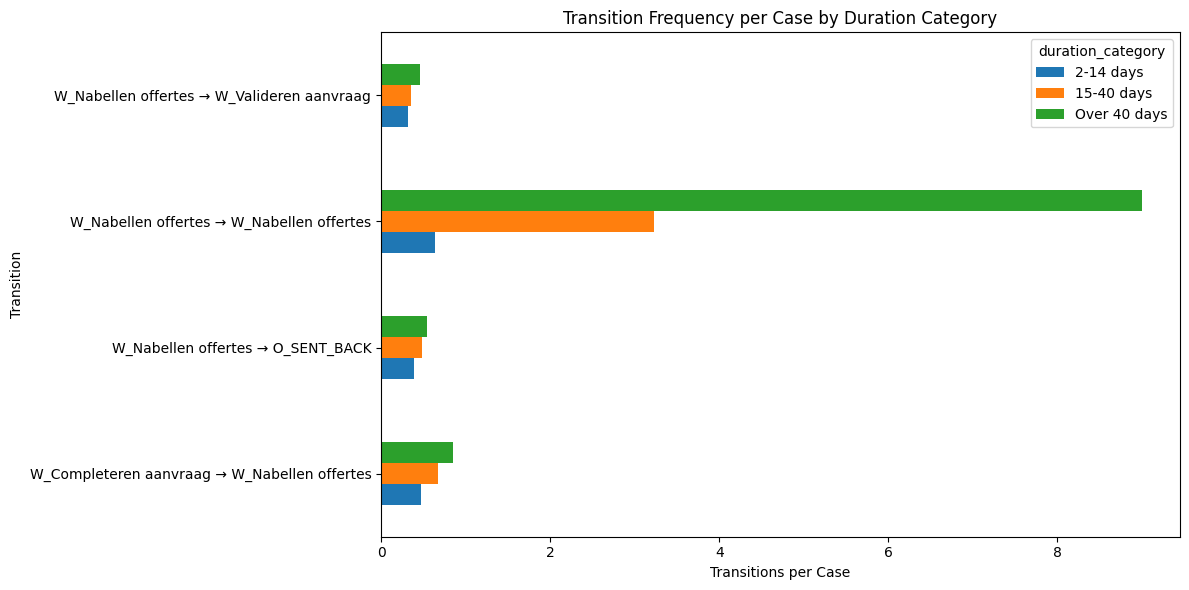

In [63]:
import matplotlib.pyplot as plt

duration_order = ["2-14 days", "15-40 days", "Over 40 days"]

plot_df = transition_comparison.copy()

selected_transitions = [
    "W_Nabellen offertes → W_Nabellen offertes",
    "W_Nabellen offertes → O_SENT_BACK",
    "W_Nabellen offertes → W_Valideren aanvraag",
    "W_Completeren aanvraag → W_Nabellen offertes"
]

plot_df = plot_df[plot_df["transition"].isin(selected_transitions)]

transition_rate_pivot = plot_df.pivot_table(
    index="transition",
    columns="duration_category",
    values="transitions_per_case"
)

transition_rate_pivot = transition_rate_pivot[duration_order]

transition_rate_pivot.plot(kind="barh", figsize=(12, 6))

plt.title("Transition Frequency per Case by Duration Category")
plt.xlabel("Transitions per Case")
plt.ylabel("Transition")
plt.tight_layout()
plt.show()

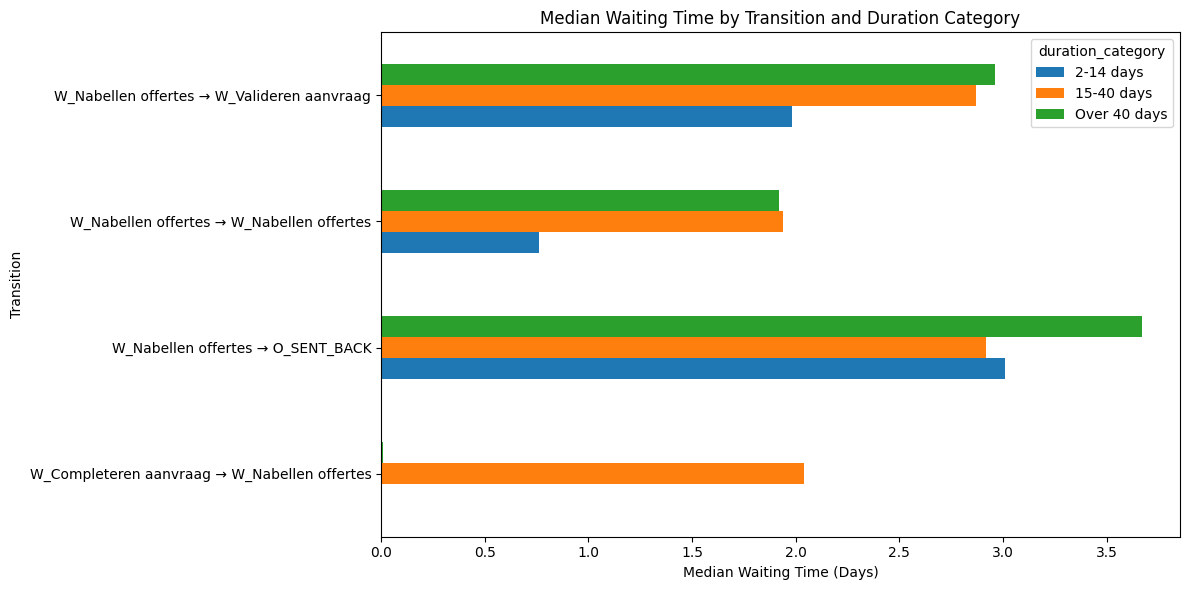

In [64]:
median_wait_pivot = plot_df.pivot_table(
    index="transition",
    columns="duration_category",
    values="median_wait_days"
)

median_wait_pivot = median_wait_pivot[duration_order]

median_wait_pivot.plot(kind="barh", figsize=(12, 6))

plt.title("Median Waiting Time by Transition and Duration Category")
plt.xlabel("Median Waiting Time (Days)")
plt.ylabel("Transition")
plt.tight_layout()
plt.show()

#Final EDA Conclusion

The exploratory analysis shows that the loan application process contains a strong imbalance between short cases and delayed cases. Most cases are completed quickly, but a smaller group of cases takes much longer, creating a long right tail in the case duration distribution.

The repetition analysis showed that delayed cases are strongly associated with repeated workflow activities, especially W_Nabellen offertes, W_Completeren aanvraag, W_Valideren aanvraag, and W_Nabellen incomplete dossiers. However, these activities are also among the most common activities in the dataset, so repetition alone does not prove that they directly cause delays.

The activity duration analysis showed that individual workflow tasks are usually completed quickly. Most median task execution times are below one hour, and several activities have median durations of only a few minutes. This suggests that long case durations are unlikely to be mainly caused by employees spending many hours executing individual tasks.

The waiting-time analysis provided a clearer explanation of the delay pattern. The transition W_Nabellen offertes → W_Nabellen offertes increases strongly across duration categories. In cases lasting 2–14 days, this transition occurs 0.64 times per case, while in cases lasting more than 40 days it increases to 9.00 transitions per case. The median waiting time between these repeated offer follow-up activities is also around two days in delayed cases.

This suggests that the main source of delay is not the duration of individual tasks, but repeated follow-up cycles and waiting time between activities. Very delayed cases appear to be characterized by repeated offer follow-up, repeated process loops, and offer-related waiting periods.

Overall, the EDA identifies W_Nabellen offertes as the most important candidate for further bottleneck investigation. The next stage of the project should focus on turning these findings into business metrics and dashboard views that help monitor delayed cases, repeated follow-up cycles, and waiting-time bottlenecks.